<a href="https://colab.research.google.com/github/ysuter/FHNW-BSUD-Part2/blob/main/L09/text_mining_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Text Mining & Embeddings
## From Words to Meaning: Classical NLP to Neural Embeddings

**Course**: Big, Semi- and Unstructured Data  
**Duration**: 3 hours  
**Topics**: Bag-of-Words, Word2Vec, BERT, Semantic Search

---

### 📚 Learning Objectives
By the end of this workshop, you will:
- Understand how to represent text as numerical vectors
- Explore pre-trained word embeddings (Word2Vec, GloVe)
- Train custom word embeddings on domain-specific data
- Use contextual embeddings (BERT) for advanced NLP
- Build a semantic search engine
- Compare classical vs. modern approaches on a real task

---

## 🔧 Setup: Install Required Libraries

Run this cell first to install all necessary packages.

In [34]:
# Install required packages
!pip install numpy
!pip install gensim
!pip install transformers
!pip install sentence-transformers
!pip install datasets
!pip install scikit-learn
!pip install nltk
!pip install plotly
!pip install umap-learn

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [35]:
# Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---

# Part 1: Quick Refresher - Bag of Words

## 🎒 What is Bag-of-Words?

**Core idea**: Represent text as a "bag" (multiset) of its words, ignoring grammar and word order.

**Example**:
- Document 1: "I love this phone"
- Document 2: "This phone is great"
- Vocabulary: [I, love, this, phone, is, great]
- Doc1 vector: [1, 1, 1, 1, 0, 0]
- Doc2 vector: [0, 0, 1, 1, 1, 1]

### ⚠️ Key Limitations:
1. **No word order**: "dog bites man" = "man bites dog"
2. **No semantics**: "good" and "great" are treated as completely different
3. **High dimensionality**: Vocabulary size = vector dimension (often 10,000+)
4. **Sparse vectors**: Mostly zeros

In [36]:
# Simple Bag-of-Words example
from sklearn.feature_extraction.text import CountVectorizer

# Sample documents
documents = [
    "I love this phone",
    "This phone is great",
    "I hate this terrible phone"
]

# Create BoW representation
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(documents)

# Display vocabulary and vectors
print("📖 Vocabulary:", vectorizer.get_feature_names_out())
print("\n📊 Document Vectors:")
print(bow_matrix.toarray())

# Create a nice DataFrame for visualization
df_bow = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"Doc {i+1}" for i in range(len(documents))]
)

print("\n📋 Document-Term Matrix:")
display(df_bow)

📖 Vocabulary: ['great' 'hate' 'is' 'love' 'phone' 'terrible' 'this']

📊 Document Vectors:
[[0 0 0 1 1 0 1]
 [1 0 1 0 1 0 1]
 [0 1 0 0 1 1 1]]

📋 Document-Term Matrix:


,great,hate,is,love,phone,terrible,this
Doc 1,0,0,0,1,1,0,1
Doc 2,1,0,1,0,1,0,1
Doc 3,0,1,0,0,1,1,1


### 🧪 Interactive Exercise: Predict the Vectors

Before running the next cell, try to predict what the vectors will look like!

In [37]:
# Exercise: What will these vectors look like?
new_documents = [
    "great phone",
    "phone great",  # Same words, different order
    "excellent phone"  # Similar meaning, different word
]

# TODO: Discuss with your neighbor - will doc 1 and 2 be identical?
# TODO: Will doc 1 and 3 be similar even though they mean the same thing?

new_bow = vectorizer.transform(new_documents)

print("📊 New Document Vectors:")
df_new = pd.DataFrame(
    new_bow.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=["great phone", "phone great", "excellent phone"]
)
display(df_new)

# Calculate similarity
sim_1_2 = cosine_similarity(new_bow[0], new_bow[1])[0][0]
sim_1_3 = cosine_similarity(new_bow[0], new_bow[2])[0][0]

print(f"\n📏 Similarity 'great phone' vs 'phone great': {sim_1_2:.3f}")
print(f"📏 Similarity 'great phone' vs 'excellent phone': {sim_1_3:.3f}")
print("\n💡 Insight: Word order doesn't matter (docs 1&2 identical), but semantics are lost!")

📊 New Document Vectors:


,great,hate,is,love,phone,terrible,this
great phone,1,0,0,0,1,0,0
phone great,1,0,0,0,1,0,0
excellent phone,0,0,0,0,1,0,0



📏 Similarity 'great phone' vs 'phone great': 1.000
📏 Similarity 'great phone' vs 'excellent phone': 0.707

💡 Insight: Word order doesn't matter (docs 1&2 identical), but semantics are lost!


---

# Part 2: Text Preprocessing

## 🧹 Why Preprocessing Matters

Raw text is messy! Before creating vectors, we need to clean and normalize.

In [38]:
# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

print("✅ NLTK data downloaded!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ NLTK data downloaded!


[nltk_data]   Package omw-1.4 is already up-to-date!


In [39]:
# Messy text example
messy_text = """OMG!!! The CATS are running so fast... They're amazing! 🐱
                Cat runs. CATS RAN!!! #CatsOfInstagram"""

print("🗑️ Original messy text:")
print(messy_text)
print("\n" + "="*60 + "\n")

# Step-by-step preprocessing
def preprocess_text(text, level="full"):
    """
    Preprocess text with different levels of cleaning.

    Parameters:
    - level: "none", "basic", or "full"
    """
    if level == "none":
        return text

    # Basic preprocessing
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation and emojis

    # Ensure punkt_tab is downloaded
    import nltk
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab', quiet=True)

    tokens = word_tokenize(text)  # Tokenize

    if level == "basic":
        return tokens

    # Full preprocessing
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords

    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word, pos='v') for word in tokens]  # Lemmatize

    return tokens

# Compare preprocessing levels
print("1️⃣ No preprocessing:")
print(preprocess_text(messy_text, "none"))

print("\n2️⃣ Basic (lowercase + tokenize + clean):")
print(preprocess_text(messy_text, "basic"))

print("\n3️⃣ Full (+ stopwords + lemmatization):")
result = preprocess_text(messy_text, "full")
print(result)

print("\n💡 Notice: 'cats', 'Cat', 'CATS', 'running', 'runs', 'RAN' → all become 'cat' and 'run'!")

🗑️ Original messy text:
OMG!!! The CATS are running so fast... They're amazing! 🐱
                Cat runs. CATS RAN!!! #CatsOfInstagram


1️⃣ No preprocessing:
OMG!!! The CATS are running so fast... They're amazing! 🐱
                Cat runs. CATS RAN!!! #CatsOfInstagram

2️⃣ Basic (lowercase + tokenize + clean):
['omg', 'the', 'cats', 'are', 'running', 'so', 'fast', 'theyre', 'amazing', 'cat', 'runs', 'cats', 'ran', 'catsofinstagram']

3️⃣ Full (+ stopwords + lemmatization):
['omg', 'cat', 'run', 'fast', 'theyre', 'amaze', 'cat', 'run', 'cat', 'run', 'catsofinstagram']

💡 Notice: 'cats', 'Cat', 'CATS', 'running', 'runs', 'RAN' → all become 'cat' and 'run'!


### ✏️ Your Turn: Preprocess a Social Media Post

In [40]:
# TODO: Preprocess this social media post
your_text = """WOW!!! Just bought this AMAZING product...
               It's working perfectly! Best purchase EVER! 😍 #happy #recommendation"""

# TODO: Apply full preprocessing
# Uncomment and complete:
# processed = preprocess_text(your_text, level="...")
# print(processed)

# SOLUTION (uncomment to see)
processed = preprocess_text(your_text, level="full")
print("Processed tokens:", processed)

Processed tokens: ['wow', 'buy', 'amaze', 'product', 'work', 'perfectly', 'best', 'purchase', 'ever', 'happy', 'recommendation']


---

# Part 3: The Semantic Gap Problem

## ❌ Why Count-Based Methods Fail

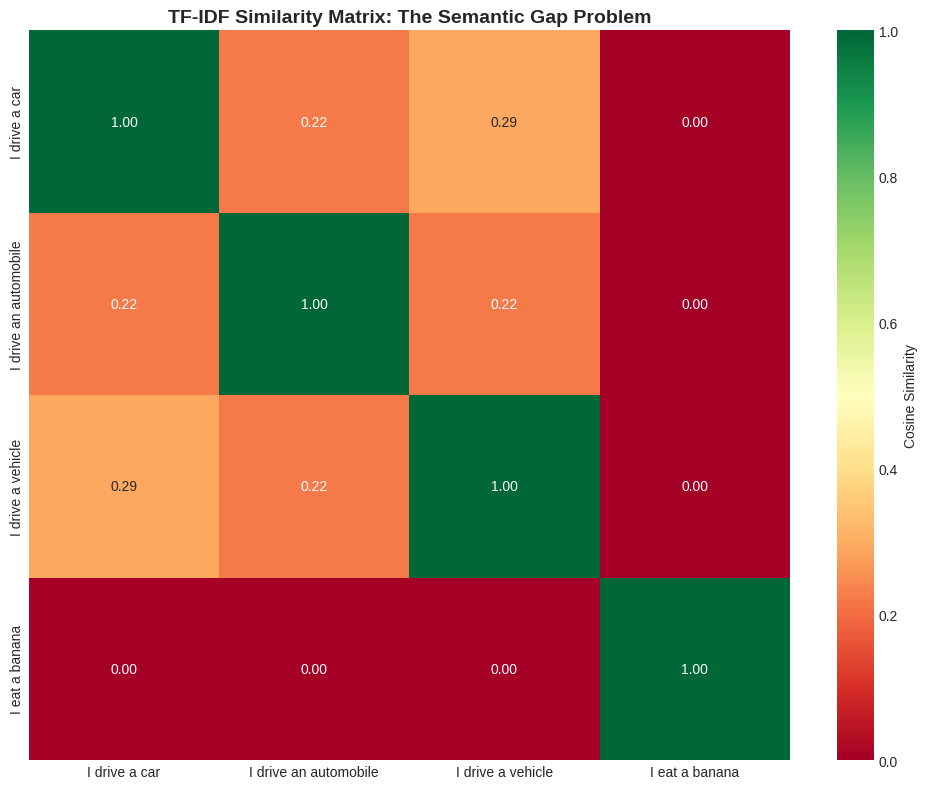


⚠️ THE PROBLEM:
Similarity 'car' vs 'automobile': 0.221
Similarity 'car' vs 'vehicle': 0.289
Similarity 'car' vs 'banana': 0.000

💡 'car' and 'automobile' are as different as 'car' and 'banana'!

✨ Solution: Word Embeddings! Similar words → similar vectors


In [41]:
# Demonstrate the semantic gap
from sklearn.feature_extraction.text import TfidfVectorizer

# Similar words (semantically) but different spelling
corpus = [
    "I drive a car",
    "I drive an automobile",
    "I drive a vehicle",
    "I eat a banana"
]

# Create TF-IDF vectors
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(corpus)

# Calculate similarities
similarities = cosine_similarity(tfidf_matrix)

# Visualize similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(similarities,
            annot=True,
            fmt='.2f',
            xticklabels=corpus,
            yticklabels=corpus,
            cmap='RdYlGn',
            vmin=0, vmax=1,
            cbar_kws={'label': 'Cosine Similarity'})
plt.title('TF-IDF Similarity Matrix: The Semantic Gap Problem', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️ THE PROBLEM:")
print(f"Similarity 'car' vs 'automobile': {similarities[0][1]:.3f}")
print(f"Similarity 'car' vs 'vehicle': {similarities[0][2]:.3f}")
print(f"Similarity 'car' vs 'banana': {similarities[0][3]:.3f}")
print("\n💡 'car' and 'automobile' are as different as 'car' and 'banana'!")
print("\n✨ Solution: Word Embeddings! Similar words → similar vectors")

---

# 🚀 DEMO 1: Exploring Pre-trained Word2Vec Embeddings

## 📖 Word2Vec

**Core idea**: "You shall know a word by the company it keeps"

**Word2Vec maps words to dense vectors** (typically 100-300 dimensions) where:
- Similar words have similar vectors
- Vector arithmetic captures semantic relationships
- Trained on massive corpora (Google News, Wikipedia, etc.)

In [42]:
# Download pre-trained Word2Vec model (this may take a few minutes)
import gensim.downloader as api

print("📥 Downloading pre-trained Word2Vec model (Google News, 100B words)...")
print("⏳ This may take 2-3 minutes...\n")

# Load a smaller, faster model (alternatively use 'word2vec-google-news-300' for full model)
word2vec_model = api.load('glove-wiki-gigaword-100')  # 100-dim, faster

print("✅ Model loaded successfully!")
print(f"📊 Vocabulary size: {len(word2vec_model):,} words")
print(f"📏 Vector dimension: {word2vec_model.vector_size}")

📥 Downloading pre-trained Word2Vec model (Google News, 100B words)...
⏳ This may take 2-3 minutes...

✅ Model loaded successfully!
📊 Vocabulary size: 400,000 words
📏 Vector dimension: 100


## 🔍 Exploration 1: Finding Similar Words

In [43]:
# Find words similar to a given word
def explore_similar_words(word, model, top_n=10):
    """
    Find and display the most similar words to the given word.
    """
    try:
        similar_words = model.most_similar(word, topn=top_n)

        print(f"\n🔍 Top {top_n} words similar to '{word}':")
        print("=" * 50)

        for i, (sim_word, similarity) in enumerate(similar_words, 1):
            print(f"{i:2d}. {sim_word:20s} (similarity: {similarity:.4f})")

        return similar_words

    except KeyError:
        print(f"❌ Word '{word}' not in vocabulary!")
        return None

# Try different words
explore_similar_words('king', word2vec_model)
explore_similar_words('computer', word2vec_model)
explore_similar_words('happy', word2vec_model)


🔍 Top 10 words similar to 'king':
 1. prince               (similarity: 0.7682)
 2. queen                (similarity: 0.7508)
 3. son                  (similarity: 0.7021)
 4. brother              (similarity: 0.6986)
 5. monarch              (similarity: 0.6978)
 6. throne               (similarity: 0.6920)
 7. kingdom              (similarity: 0.6811)
 8. father               (similarity: 0.6802)
 9. emperor              (similarity: 0.6713)
10. ii                   (similarity: 0.6676)

🔍 Top 10 words similar to 'computer':
 1. computers            (similarity: 0.8752)
 2. software             (similarity: 0.8373)
 3. technology           (similarity: 0.7642)
 4. pc                   (similarity: 0.7366)
 5. hardware             (similarity: 0.7290)
 6. internet             (similarity: 0.7287)
 7. desktop              (similarity: 0.7234)
 8. electronic           (similarity: 0.7222)
 9. systems              (similarity: 0.7198)
10. computing            (similarity: 0.7142)

🔍 Top

[("'m", 0.8413287997245789),
 ('feel', 0.8132575750350952),
 ("'re", 0.8048083186149597),
 ('i', 0.7938276529312134),
 ("'ll", 0.7916273474693298),
 ('really', 0.7903971076011658),
 ('glad', 0.7833361029624939),
 ('good', 0.7821646332740784),
 ('we', 0.7808917164802551),
 ('sure', 0.7788466215133667)]

## 🧮 Exploration 2: Word Analogies (The Famous King - Man + Woman = ?)

In [44]:
# Word analogies: A is to B as C is to ?
def word_analogy(word_a, word_b, word_c, model, top_n=5):
    """
    Compute: word_a - word_b + word_c = ?
    Example: king - man + woman = queen
    """
    try:
        result = model.most_similar(positive=[word_a, word_c], negative=[word_b], topn=top_n)

        print(f"\n🧮 {word_a} - {word_b} + {word_c} = ?")
        print("=" * 50)

        for i, (word, similarity) in enumerate(result, 1):
            print(f"{i}. {word:20s} (similarity: {similarity:.4f})")

        return result

    except KeyError as e:
        print(f"❌ Word not in vocabulary: {e}")
        return None

# Famous examples
print("\n👑 Gender analogies:")
word_analogy('king', 'man', 'woman', word2vec_model)

print("\n🌍 Country-Capital analogies:")
word_analogy('paris', 'france', 'italy', word2vec_model)

print("\n📖 Verb tense analogies:")
word_analogy('walking', 'walk', 'swim', word2vec_model)


👑 Gender analogies:

🧮 king - man + woman = ?
1. queen                (similarity: 0.7699)
2. monarch              (similarity: 0.6843)
3. throne               (similarity: 0.6756)
4. daughter             (similarity: 0.6595)
5. princess             (similarity: 0.6521)

🌍 Country-Capital analogies:

🧮 paris - france + italy = ?
1. rome                 (similarity: 0.8190)
2. milan                (similarity: 0.7376)
3. naples               (similarity: 0.7118)
4. venice               (similarity: 0.7015)
5. turin                (similarity: 0.6995)

📖 Verb tense analogies:

🧮 walking - walk + swim = ?
1. swimming             (similarity: 0.8009)
2. surfing              (similarity: 0.6603)
3. swam                 (similarity: 0.6448)
4. rowing               (similarity: 0.6413)
5. jogging              (similarity: 0.6376)


[('swimming', 0.8008804321289062),
 ('surfing', 0.6602576375007629),
 ('swam', 0.6447523832321167),
 ('rowing', 0.6412530541419983),
 ('jogging', 0.637580931186676)]

## 📊 Exploration 3: Calculate Similarity Scores


📏 Word Pair Similarities:
car             ↔ automobile      : 0.6832
car             ↔ vehicle         : 0.8631
car             ↔ banana          : 0.1486
happy           ↔ joyful          : 0.5260
happy           ↔ sad             : 0.6801
cat             ↔ dog             : 0.8798
cat             ↔ computer        : 0.2975


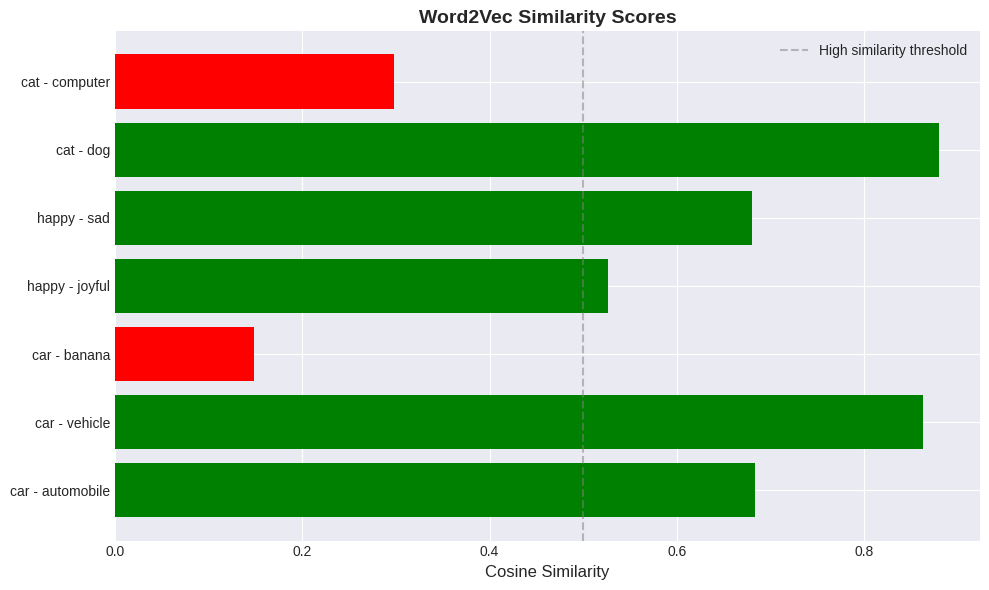


💡 Compare this to the TF-IDF results earlier!
✨ Now 'car' and 'automobile' are recognized as similar!


In [45]:
# Direct similarity calculations
word_pairs = [
    ('car', 'automobile'),
    ('car', 'vehicle'),
    ('car', 'banana'),
    ('happy', 'joyful'),
    ('happy', 'sad'),
    ('cat', 'dog'),
    ('cat', 'computer')
]

print("\n📏 Word Pair Similarities:")
print("=" * 60)

results = []
for word1, word2 in word_pairs:
    try:
        sim = word2vec_model.similarity(word1, word2)
        results.append((word1, word2, sim))
        print(f"{word1:15s} ↔ {word2:15s} : {sim:.4f}")
    except KeyError:
        print(f"{word1:15s} ↔ {word2:15s} : Not in vocabulary")

# Visualize
df_sim = pd.DataFrame(results, columns=['Word 1', 'Word 2', 'Similarity'])

plt.figure(figsize=(10, 6))
colors = ['green' if s > 0.5 else 'orange' if s > 0.3 else 'red' for s in df_sim['Similarity']]
plt.barh([f"{w1} - {w2}" for w1, w2 in zip(df_sim['Word 1'], df_sim['Word 2'])],
         df_sim['Similarity'],
         color=colors)
plt.xlabel('Cosine Similarity', fontsize=12)
plt.title('Word2Vec Similarity Scores', fontsize=14, fontweight='bold')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='High similarity threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 Compare this to the TF-IDF results earlier!")
print("✨ Now 'car' and 'automobile' are recognized as similar!")

## ✏️ YOUR TURN: Exploration Challenge

Find 3 interesting word relationships using the embedding space!

In [46]:
# TODO: Explore the embedding space and find interesting relationships
# Try:
# 1. Find synonyms for a word you're interested in
# 2. Try creative analogies (e.g., doctor - hospital + school = ?)
# 3. Compare unexpected word pairs

# Example starter code:
# explore_similar_words('YOUR_WORD', word2vec_model)
# word_analogy('WORD_A', 'WORD_B', 'WORD_C', word2vec_model)
# word2vec_model.similarity('WORD_1', 'WORD_2')

# YOUR CODE HERE:



---

# 🚀 DEMO 2: Training Custom Word2Vec Embeddings

## 🎯 Why Train Your Own?

Pre-trained models are great, but sometimes you need **domain-specific embeddings**:
- Medical texts with specialized terminology
- Legal documents with specific jargon
- Company-specific product names
- Social media slang and hashtags

Let's train embeddings on **Amazon product reviews**!

In [47]:
# Create a sample corpus (in practice, use much more data!)
# Simulating product reviews

sample_reviews = [
    "This smartphone is excellent fast performance great battery life",
    "Amazing phone superb camera quality wonderful display",
    "Love this device perfect for gaming smooth performance",
    "Great laptop powerful processor fast computing",
    "Fantastic computer excellent for work wonderful keyboard",
    "Superb laptop great performance amazing build quality",
    "Terrible phone poor battery awful camera",
    "Horrible device worst purchase terrible quality",
    "Bad laptop slow performance poor build",
    "Disappointing computer awful experience terrible design",
    "The camera takes stunning photos excellent image quality",
    "Great camera wonderful picture quality superb zoom",
    "Amazing photos beautiful images perfect camera",
    "Excellent headphones great sound quality wonderful bass",
    "Fantastic audio amazing sound superb headphones",
    "Perfect sound quality great headphones wonderful experience",
    # Add more diverse reviews
] * 10  # Repeat for more training data

# Preprocess reviews (tokenize)
from gensim.models import Word2Vec

# Tokenize sentences
tokenized_reviews = [review.lower().split() for review in sample_reviews]

print(f"📊 Training data: {len(tokenized_reviews)} reviews")
print(f"📝 Example review: {tokenized_reviews[0]}")

📊 Training data: 160 reviews
📝 Example review: ['this', 'smartphone', 'is', 'excellent', 'fast', 'performance', 'great', 'battery', 'life']


In [48]:
# Train Word2Vec model
print("🏋️ Training custom Word2Vec model...\n")

custom_w2v = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,        # Embedding dimension
    window=5,               # Context window size
    min_count=2,           # Ignore words that appear less than this
    workers=4,             # Number of CPU cores to use
    epochs=20,             # Number of training iterations
    sg=1                   # 1 = skip-gram, 0 = CBOW
)

print("✅ Model trained successfully!")
print(f"📊 Vocabulary size: {len(custom_w2v.wv)} words")
print(f"📏 Vector dimension: {custom_w2v.wv.vector_size}")
print(f"\n📖 Sample vocabulary: {list(custom_w2v.wv.index_to_key)[:20]}")

🏋️ Training custom Word2Vec model...

✅ Model trained successfully!
📊 Vocabulary size: 55 words
📏 Vector dimension: 100

📖 Sample vocabulary: ['quality', 'great', 'wonderful', 'camera', 'superb', 'amazing', 'performance', 'excellent', 'sound', 'headphones', 'terrible', 'laptop', 'perfect', 'photos', 'experience', 'awful', 'poor', 'build', 'computer', 'fantastic']


## 🔍 Test Your Custom Embeddings

In [49]:
# Find similar words in custom embeddings
test_words = ['excellent', 'phone', 'terrible', 'camera']

for word in test_words:
    if word in custom_w2v.wv:
        similar = custom_w2v.wv.most_similar(word, topn=5)
        print(f"\n🔍 Words similar to '{word}':")
        for sim_word, score in similar:
            print(f"  - {sim_word:15s} (similarity: {score:.3f})")
    else:
        print(f"\n❌ '{word}' not in vocabulary")

# Compare custom vs pre-trained
print("\n" + "="*60)
print("📊 Comparison: Custom vs Pre-trained embeddings")
print("="*60)

test_word = 'excellent'
if test_word in custom_w2v.wv:
    print(f"\n🏷️ Custom model - similar to '{test_word}':")
    for word, score in custom_w2v.wv.most_similar(test_word, topn=5):
        print(f"  {word:15s} {score:.3f}")

if test_word in word2vec_model:
    print(f"\n🌍 Pre-trained model - similar to '{test_word}':")
    for word, score in word2vec_model.most_similar(test_word, topn=5):
        print(f"  {word:15s} {score:.3f}")

print("\n💡 Custom models learn domain-specific associations!")


🔍 Words similar to 'excellent':
  - performance     (similarity: 0.990)
  - quality         (similarity: 0.990)
  - for             (similarity: 0.989)
  - fast            (similarity: 0.989)
  - this            (similarity: 0.988)

🔍 Words similar to 'phone':
  - great           (similarity: 0.973)
  - this            (similarity: 0.970)
  - terrible        (similarity: 0.969)
  - for             (similarity: 0.969)
  - awful           (similarity: 0.969)

🔍 Words similar to 'terrible':
  - performance     (similarity: 0.988)
  - excellent       (similarity: 0.988)
  - quality         (similarity: 0.987)
  - for             (similarity: 0.987)
  - device          (similarity: 0.986)

🔍 Words similar to 'camera':
  - performance     (similarity: 0.989)
  - great           (similarity: 0.988)
  - for             (similarity: 0.987)
  - excellent       (similarity: 0.987)
  - quality         (similarity: 0.987)

📊 Comparison: Custom vs Pre-trained embeddings

🏷️ Custom model - similar t

## 📊 Visualize Custom Embeddings

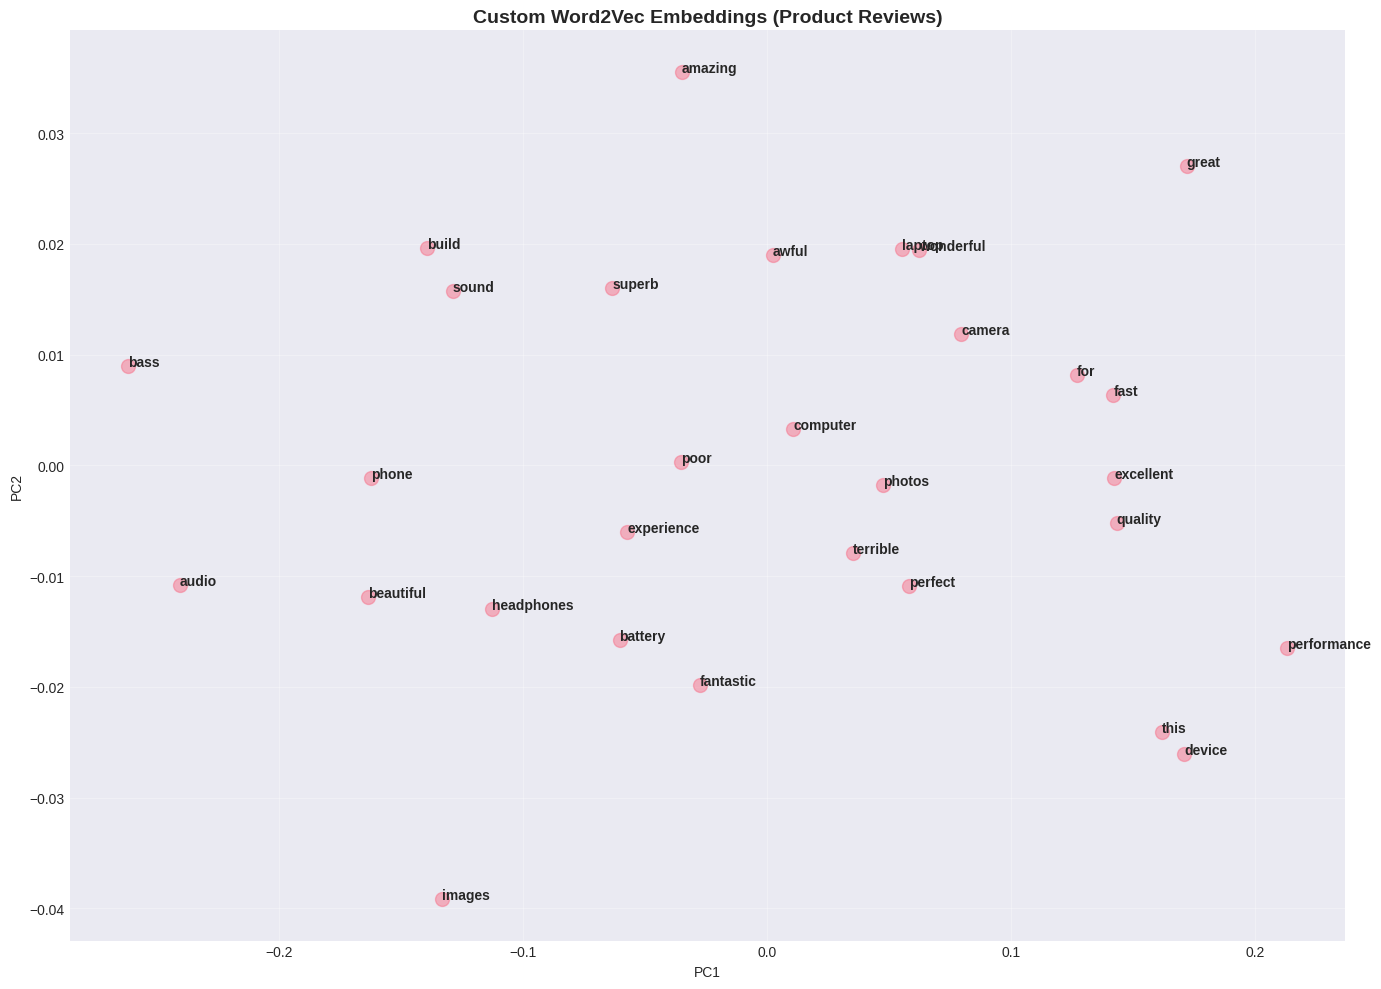


💡 Notice how sentiment words (positive/negative) cluster separately!


In [50]:
# Visualize custom embeddings
words_to_plot = list(custom_w2v.wv.index_to_key)[:30]  # Top 30 most frequent words
vectors_to_plot = [custom_w2v.wv[word] for word in words_to_plot]

# Reduce to 2D
pca = PCA(n_components=2, random_state=42)
vectors_2d = pca.fit_transform(vectors_to_plot)

# Plot
plt.figure(figsize=(14, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], s=100, alpha=0.5)

for i, word in enumerate(words_to_plot):
    plt.annotate(word,
                (vectors_2d[i, 0], vectors_2d[i, 1]),
                fontsize=10,
                fontweight='bold')

plt.title('Custom Word2Vec Embeddings (Product Reviews)', fontsize=14, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Notice how sentiment words (positive/negative) cluster separately!")

# 🚀 DEMO 3: BERT - Contextual Embeddings

## ⚠️ The Context Problem

**Limitation of Word2Vec**: Each word gets ONE vector, regardless of context.

### Example:
- "I went to the **bank** to deposit money" 🏦
- "I sat on the river **bank** to relax" 🏞️

Word2Vec gives "bank" the SAME vector in both cases!

## ✨ Solution: BERT (Bidirectional Encoder Representations from Transformers)

**Key innovation**: Embeddings that **change based on context**!

### How BERT Works:
1. **Self-Attention**: Each word "looks at" all other words
2. **Bidirectional**: Considers context from both left and right
3. **Deep**: Multiple transformer layers capture nuanced meaning
4. **Pre-trained**: Learned from massive text corpora

In [51]:
# Load BERT model
from transformers import BertTokenizer, BertModel
import torch

print("📥 Loading BERT model...")
print("⏳ This may take a minute...\n")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

print("✅ BERT model loaded successfully!")
print(f"📊 Model size: {sum(p.numel() for p in bert_model.parameters()):,} parameters")
print(f"📏 Embedding dimension: {bert_model.config.hidden_size}")

📥 Loading BERT model...
⏳ This may take a minute...

✅ BERT model loaded successfully!
📊 Model size: 109,482,240 parameters
📏 Embedding dimension: 768


## 🔍 Demonstration: Context Changes Embeddings

In [52]:
def get_bert_embedding(sentence, word, tokenizer, model):
    """
    Get BERT embedding for a specific word in a sentence.
    """
    # Tokenize
    inputs = tokenizer(sentence, return_tensors='pt', padding=True, truncation=True)

    # Get embeddings
    with torch.no_grad():
        outputs = model(**inputs)

    # Get last hidden state
    last_hidden_state = outputs.last_hidden_state[0]  # Shape: [seq_len, hidden_size]

    # Find the token for our target word
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    word_token = tokenizer.tokenize(word)[0]

    # Find position of word
    try:
        word_idx = tokens.index(word_token)
        word_embedding = last_hidden_state[word_idx].numpy()
        return word_embedding
    except ValueError:
        print(f"⚠️ Could not find '{word}' in tokenized sentence")
        return None

# Test with the "bank" example
sentence1 = "I went to the bank to deposit money"
sentence2 = "I sat on the river bank"

print("🏦 Sentence 1:", sentence1)
print("🏞️ Sentence 2:", sentence2)
print("\n" + "="*60)

# Get embeddings for "bank" in both contexts
bank_emb1 = get_bert_embedding(sentence1, "bank", tokenizer, bert_model)
bank_emb2 = get_bert_embedding(sentence2, "bank", tokenizer, bert_model)

if bank_emb1 is not None and bank_emb2 is not None:
    # Calculate similarity
    similarity = cosine_similarity([bank_emb1], [bank_emb2])[0][0]

    print(f"\n📏 Similarity between 'bank' in both contexts: {similarity:.4f}")
    print("\n💡 Notice: The similarity is NOT 1.0!")
    print("✨ BERT creates different embeddings based on context!")

    # Compare to Word2Vec (static embedding)
    if 'bank' in word2vec_model:
        w2v_bank = word2vec_model['bank']
        w2v_similarity = cosine_similarity([w2v_bank], [w2v_bank])[0][0]
        print(f"\n📊 Word2Vec 'bank' vs 'bank': {w2v_similarity:.4f} (always 1.0!)")
        print("⚠️ Word2Vec cannot distinguish different meanings!")

🏦 Sentence 1: I went to the bank to deposit money
🏞️ Sentence 2: I sat on the river bank


📏 Similarity between 'bank' in both contexts: 0.3273

💡 Notice: The similarity is NOT 1.0!
✨ BERT creates different embeddings based on context!

📊 Word2Vec 'bank' vs 'bank': 1.0000 (always 1.0!)
⚠️ Word2Vec cannot distinguish different meanings!


## 🧪 More Context Examples


📊 Contextual Embedding Similarities:

🔤 Word: light
  Context 1: The light in the room is bright
  Context 2: This bag is very light to carry
  📏 Similarity: 0.4284

🔤 Word: bat
  Context 1: The baseball bat is made of wood
  Context 2: The bat flew out of the cave
  📏 Similarity: 0.6121

🔤 Word: park
  Context 1: Let us go to the park for a walk
  Context 2: Please park your car in the garage
  📏 Similarity: 0.4739


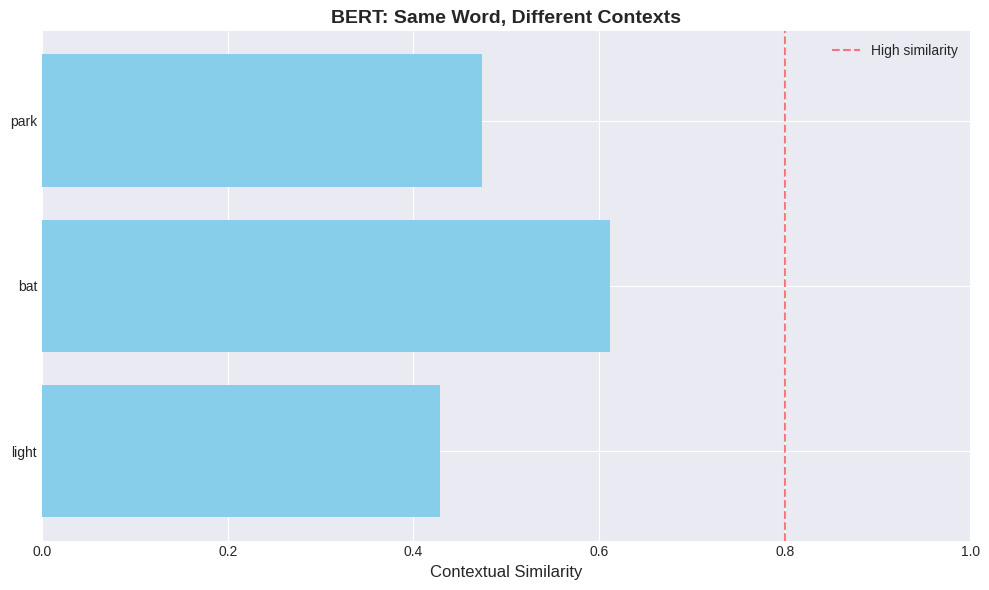


💡 Lower similarity = More context-dependent meaning!


In [53]:
# Test with multiple ambiguous words
test_cases = [
    {
        'word': 'light',
        'sentence1': 'The light in the room is bright',
        'sentence2': 'This bag is very light to carry'
    },
    {
        'word': 'bat',
        'sentence1': 'The baseball bat is made of wood',
        'sentence2': 'The bat flew out of the cave'
    },
    {
        'word': 'park',
        'sentence1': 'Let us go to the park for a walk',
        'sentence2': 'Please park your car in the garage'
    }
]

results = []

for test in test_cases:
    word = test['word']
    sent1 = test['sentence1']
    sent2 = test['sentence2']

    emb1 = get_bert_embedding(sent1, word, tokenizer, bert_model)
    emb2 = get_bert_embedding(sent2, word, tokenizer, bert_model)

    if emb1 is not None and emb2 is not None:
        sim = cosine_similarity([emb1], [emb2])[0][0]
        results.append({
            'Word': word,
            'Context 1': sent1,
            'Context 2': sent2,
            'Similarity': sim
        })

# Display results
df_context = pd.DataFrame(results)
print("\n📊 Contextual Embedding Similarities:")
print("="*80)
for _, row in df_context.iterrows():
    print(f"\n🔤 Word: {row['Word']}")
    print(f"  Context 1: {row['Context 1']}")
    print(f"  Context 2: {row['Context 2']}")
    print(f"  📏 Similarity: {row['Similarity']:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(df_context['Word'], df_context['Similarity'], color='skyblue')
plt.xlabel('Contextual Similarity', fontsize=12)
plt.title('BERT: Same Word, Different Contexts', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='High similarity')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 Lower similarity = More context-dependent meaning!")

---

# 🚀 DEMO 4: Semantic Search with Sentence-BERT

## 🎯 Goal: Build a Semantic Search Engine

**Use case**: Find documents similar to a query based on **meaning**, not just keywords!

**Sentence-BERT**: Specialized model for creating sentence embeddings optimized for semantic similarity.

In [54]:
# Load Sentence-BERT
from sentence_transformers import SentenceTransformer

print("📥 Loading Sentence-BERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast, efficient model

print("✅ Model loaded!")
print(f"📏 Embedding dimension: {sbert_model.get_sentence_embedding_dimension()}")

📥 Loading Sentence-BERT model...
✅ Model loaded!
📏 Embedding dimension: 384


In [55]:
# Create a corpus of product descriptions
corpus = [
    "Lightweight laptop perfect for students and professionals on the go",
    "Powerful gaming computer with RGB lights and high-end graphics card",
    "Portable notebook ideal for travel and remote work",
    "Desktop workstation for video editing and 3D rendering",
    "Budget-friendly tablet for browsing and reading",
    "Professional camera for photography enthusiasts",
    "Wireless headphones with noise cancellation",
    "Smartphone with excellent camera and long battery life",
    "Mechanical keyboard for gaming and typing",
    "Ergonomic mouse for comfortable long-term use",
    "4K monitor for graphic design and video editing",
    "Portable charger for phones and tablets",
    "Smart watch with fitness tracking features",
    "USB-C hub for connecting multiple devices",
    "External hard drive for backup and storage"
]

print(f"📚 Corpus size: {len(corpus)} documents")
print("\n📄 Sample documents:")
for i, doc in enumerate(corpus[:5], 1):
    print(f"{i}. {doc}")

📚 Corpus size: 15 documents

📄 Sample documents:
1. Lightweight laptop perfect for students and professionals on the go
2. Powerful gaming computer with RGB lights and high-end graphics card
3. Portable notebook ideal for travel and remote work
4. Desktop workstation for video editing and 3D rendering
5. Budget-friendly tablet for browsing and reading


In [56]:
# Encode all documents
print("🔄 Encoding corpus...")
corpus_embeddings = sbert_model.encode(corpus, convert_to_tensor=False)

print(f"✅ Encoded {len(corpus_embeddings)} documents")
print(f"📐 Embedding shape: {corpus_embeddings.shape}")

🔄 Encoding corpus...
✅ Encoded 15 documents
📐 Embedding shape: (15, 384)


## 🔍 Semantic Search Function

In [57]:
def semantic_search(query, corpus, embeddings, model, top_k=5):
    """
    Perform semantic search to find most relevant documents.

    Parameters:
    - query: Search query string
    - corpus: List of documents
    - embeddings: Pre-computed corpus embeddings
    - model: Sentence transformer model
    - top_k: Number of results to return
    """
    # Encode query
    query_embedding = model.encode([query], convert_to_tensor=False)

    # Calculate similarities
    similarities = cosine_similarity(query_embedding, embeddings)[0]

    # Get top-k results
    top_indices = np.argsort(similarities)[::-1][:top_k]

    # Display results
    print(f"\n🔍 Query: '{query}'")
    print("="*80)
    print(f"\n📊 Top {top_k} Results:\n")

    results = []
    for rank, idx in enumerate(top_indices, 1):
        score = similarities[idx]
        doc = corpus[idx]
        results.append({'Rank': rank, 'Score': score, 'Document': doc})
        print(f"{rank}. [Score: {score:.4f}] {doc}")

    return results

# Test queries
test_queries = [
    "computer for university students",
    "device for gaming",
    "equipment for photographers",
    "portable electronics"
]

for query in test_queries:
    semantic_search(query, corpus, corpus_embeddings, sbert_model, top_k=3)
    print("\n")


🔍 Query: 'computer for university students'

📊 Top 3 Results:

1. [Score: 0.6180] Lightweight laptop perfect for students and professionals on the go
2. [Score: 0.4257] Desktop workstation for video editing and 3D rendering
3. [Score: 0.4112] Budget-friendly tablet for browsing and reading



🔍 Query: 'device for gaming'

📊 Top 3 Results:

1. [Score: 0.5531] Mechanical keyboard for gaming and typing
2. [Score: 0.5469] Powerful gaming computer with RGB lights and high-end graphics card
3. [Score: 0.3830] Budget-friendly tablet for browsing and reading



🔍 Query: 'equipment for photographers'

📊 Top 3 Results:

1. [Score: 0.6309] Professional camera for photography enthusiasts
2. [Score: 0.3625] Smartphone with excellent camera and long battery life
3. [Score: 0.2595] Portable notebook ideal for travel and remote work



🔍 Query: 'portable electronics'

📊 Top 3 Results:

1. [Score: 0.6385] Portable notebook ideal for travel and remote work
2. [Score: 0.5962] Portable charger for phones

## 💡 The Power of Semantic Search

Notice how the search understands **meaning**, not just keywords:
- "computer for university" → finds "laptop for students" ✅
- "device for gaming" → finds "gaming computer" ✅
- "equipment for photographers" → finds "camera" ✅

## ✏️ YOUR TURN: Try Your Own Queries!

In [58]:
# TODO: Try your own semantic search queries!
# Examples:
# - "tools for content creators"
# - "accessories for mobile devices"
# - "equipment for remote workers"

# YOUR CODE HERE:
my_query = "YOUR QUERY HERE"
# semantic_search(my_query, corpus, corpus_embeddings, sbert_model, top_k=5)
